In [279]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [280]:
from google.colab import files
uploaded = files.upload()

Saving archive (6).zip to archive (6) (1).zip


In [281]:
import zipfile
import os

# Assuming the uploaded file is 'archive (6).zip'
zip_file_name = next(iter(uploaded)) # Get the name of the first (and likely only) uploaded file

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.') # Extract all contents to the current directory

# Now read the CSV files from the extracted directory
# Based on the zip content, the files are likely in 'banking_dataset_kaggle/data/csv/'
base_path = "banking_dataset_kaggle/data/csv/"

customers = pd.read_csv(os.path.join(base_path, "customers.csv"))
accounts = pd.read_csv(os.path.join(base_path, "accounts.csv"))
loans = pd.read_csv(os.path.join(base_path, "loans.csv"))
cards = pd.read_csv(os.path.join(base_path, "cards.csv"))

In [282]:
master = customers.merge(accounts, on="customer_id", how="left")

master = master.merge(loans, on="customer_id", how="left")

master = master.merge(cards, on="account_id", how="left")

In [283]:
master.to_csv("banking_master_dataset.csv", index=False)

In [284]:
master.shape

(150251, 18)

In [285]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150251 entries, 0 to 150250
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   customer_id      150251 non-null  object 
 1   first_name       150251 non-null  object 
 2   last_name        150251 non-null  object 
 3   email            150251 non-null  object 
 4   city             150251 non-null  object 
 5   credit_score     150251 non-null  int64  
 6   created_at       150251 non-null  object 
 7   account_id       137350 non-null  object 
 8   account_type     137350 non-null  object 
 9   balance_usd      137350 non-null  float64
 10  open_date        137350 non-null  object 
 11  loan_id          78370 non-null   object 
 12  loan_amount      78370 non-null   float64
 13  interest_rate    78370 non-null   float64
 14  start_date       78370 non-null   object 
 15  card_id          114715 non-null  object 
 16  card_type        114715 non-null  obje

In [286]:
master.dtypes

,0
customer_id,object
first_name,object
last_name,object
email,object
city,object
credit_score,int64
created_at,object
account_id,object
account_type,object
balance_usd,float64


In [287]:
master.isnull().sum()

,0
customer_id,0
first_name,0
last_name,0
email,0
city,0
credit_score,0
created_at,0
account_id,12901
account_type,12901
balance_usd,12901


In [288]:
(master.isnull().sum() / len(master)) * 100

,0
customer_id,0.000000
first_name,0.000000
last_name,0.000000
email,0.000000
city,0.000000
credit_score,0.000000
created_at,0.000000
account_id,8.586299
account_type,8.586299
balance_usd,8.586299


In [289]:
master.duplicated().sum()

np.int64(0)

In [290]:
master = master.drop_duplicates()

In [291]:
master.duplicated().sum()

np.int64(0)

In [292]:
master.nunique()

,0
customer_id,50000
first_name,690
last_name,1000
email,45773
city,25169
credit_score,551
created_at,2557
account_id,75000
account_type,3
balance_usd,74846


In [293]:
master.describe()

,credit_score,balance_usd,loan_amount,interest_rate
count,150251.000000,137350.000000,78370.000000,78370.000000
mean,574.274840,100145.152241,150642.303524,8.485911
std,158.780838,57587.915241,86042.170902,3.741344
min,300.000000,13.200000,1010.160000,2.000000
25%,437.000000,50483.360000,76333.660000,5.260000
50%,575.000000,100023.190000,151525.320000,8.480000
75%,711.000000,149878.605000,224809.587500,11.720000
max,850.000000,199994.580000,299975.470000,15.000000


In [294]:
master["account_type"].value_counts()

,count
account_type,
Checking,46216
Savings,45592
Business,45542


In [295]:
master["card_type"].value_counts()

,count
card_type,
Debit,57675
Credit,57040


In [296]:
print(master.columns.tolist())

['customer_id', 'first_name', 'last_name', 'email', 'city', 'credit_score', 'created_at', 'account_id', 'account_type', 'balance_usd', 'open_date', 'loan_id', 'loan_amount', 'interest_rate', 'start_date', 'card_id', 'card_type', 'expiration_date']


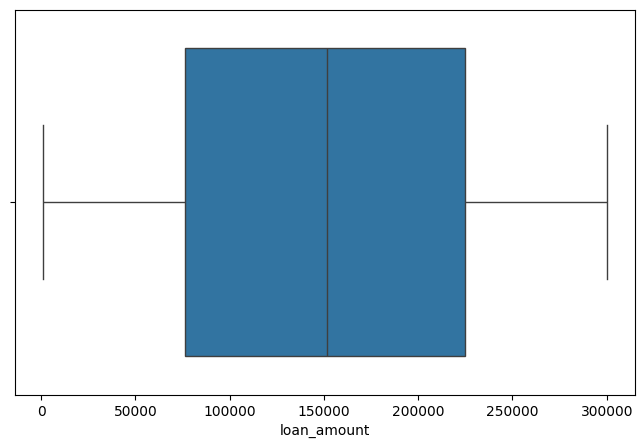

In [297]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=master["loan_amount"])
plt.show()

In [298]:
# master["customer_id"] = master["customer_id"].astype(int) # This line was causing an error due to non-numeric IDs.

In [299]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150251 entries, 0 to 150250
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   customer_id      150251 non-null  object 
 1   first_name       150251 non-null  object 
 2   last_name        150251 non-null  object 
 3   email            150251 non-null  object 
 4   city             150251 non-null  object 
 5   credit_score     150251 non-null  int64  
 6   created_at       150251 non-null  object 
 7   account_id       137350 non-null  object 
 8   account_type     137350 non-null  object 
 9   balance_usd      137350 non-null  float64
 10  open_date        137350 non-null  object 
 11  loan_id          78370 non-null   object 
 12  loan_amount      78370 non-null   float64
 13  interest_rate    78370 non-null   float64
 14  start_date       78370 non-null   object 
 15  card_id          114715 non-null  object 
 16  card_type        114715 non-null  obje

In [300]:
master.columns.tolist()

['customer_id',
 'first_name',
 'last_name',
 'email',
 'city',
 'credit_score',
 'created_at',
 'account_id',
 'account_type',
 'balance_usd',
 'open_date',
 'loan_id',
 'loan_amount',
 'interest_rate',
 'start_date',
 'card_id',
 'card_type',
 'expiration_date']

In [301]:
master["created_at"] = pd.to_datetime(master["created_at"])
master["open_date"] = pd.to_datetime(master["open_date"])
master["start_date"] = pd.to_datetime(master["start_date"])
master["expiration_date"] = pd.to_datetime(master["expiration_date"])

In [302]:
master["Account_Age_Days"] = (
    pd.Timestamp.today() - master["open_date"]
).dt.days

In [303]:
master["Customer_Tenure_Days"] = (
    pd.Timestamp.today() - master["created_at"]
).dt.days

In [304]:
master["Loan_Duration_Days"] = (
    pd.Timestamp.today() - master["start_date"]
).dt.days

In [305]:
master["Card_Expiry_Days"] = (
    master["expiration_date"] - pd.Timestamp.today()
).dt.days

In [306]:
master["Loan_Balance_Ratio"] = (
    master["loan_amount"] /
    master["balance_usd"].replace(0, 1)
)

In [307]:
master["High_Loan_Customer"] = (
    master["loan_amount"] >
    master["loan_amount"].median()
).astype(int)

In [308]:
master["Premium_Customer"] = (
    (master["balance_usd"] > master["balance_usd"].median()) &
    (master["credit_score"] > 700)
).astype(int)

In [309]:
master["Total_Products"] = (
    master["account_id"].notna().astype(int) +
    master["loan_id"].notna().astype(int) +
    master["card_id"].notna().astype(int)
)

master["Balance_Per_Product"] = (
    master["balance_usd"] /
    master["Total_Products"].replace(0, 1)
)

In [310]:
master["Estimated_Interest"] = (
    master["loan_amount"] *
    master["interest_rate"] / 100
)

In [311]:
master["Card_Status"] = np.where(
    master["expiration_date"] < pd.Timestamp.today(),
    "Expired",
    "Active"
)

In [312]:
master["Account_Status"] = np.where(
    master["balance_usd"] > 0,
    "Active",
    "Inactive"
)

In [313]:
master["Customer_Value"] = (
    master["balance_usd"] +
    master["loan_amount"]
)

In [314]:
master.to_csv(
    "banking_master_dataset_feature_engineered.csv",
    index=False
)

In [315]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [316]:
features = master[
    [
        "credit_score",
        "balance_usd",
        "loan_amount",
        "interest_rate",
        "Total_Products",
        "Customer_Value"
    ]
]

In [317]:
features = master[
    [
        "credit_score",
        "balance_usd",
        "loan_amount",
        "interest_rate",
        "Total_Products",
        "Customer_Value"
    ]
]
features.isnull().sum()

,0
credit_score,0
balance_usd,12901
loan_amount,71881
interest_rate,71881
Total_Products,0
Customer_Value,78784


In [318]:
features.isnull().sum()

,0
credit_score,0
balance_usd,12901
loan_amount,71881
interest_rate,71881
Total_Products,0
Customer_Value,78784


In [319]:
features = features.fillna(features.median())

In [320]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [321]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

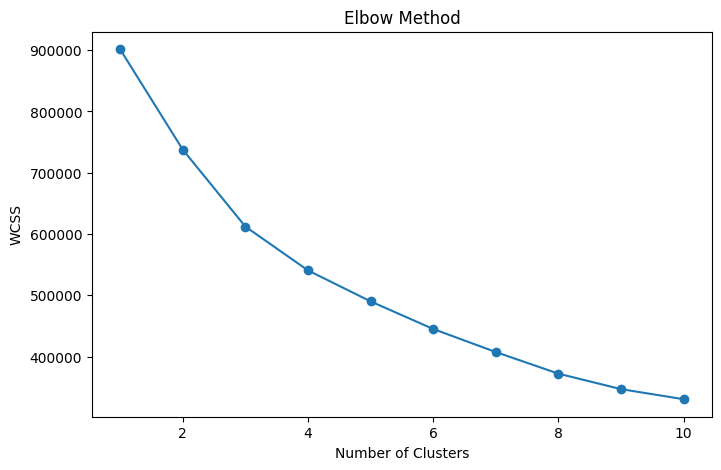

In [322]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [323]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

master["Cluster"] = kmeans.fit_predict(scaled_features)

In [324]:
master["Cluster"].value_counts()

,count
Cluster,
2,49209
1,48968
3,26061
0,26013


In [325]:
master.groupby("Cluster")[
    [
        "balance_usd",
        "loan_amount",
        "credit_score",
        "Customer_Value"
    ]
].mean()

,balance_usd,loan_amount,credit_score,Customer_Value
Cluster,,,,
0,119855.334023,237609.087584,572.260254,357464.421607
1,100690.570725,150565.049614,715.303035,250875.490856
2,99384.860959,151237.754608,432.768721,251006.313759
3,80824.827465,63570.571549,578.492307,144395.399014


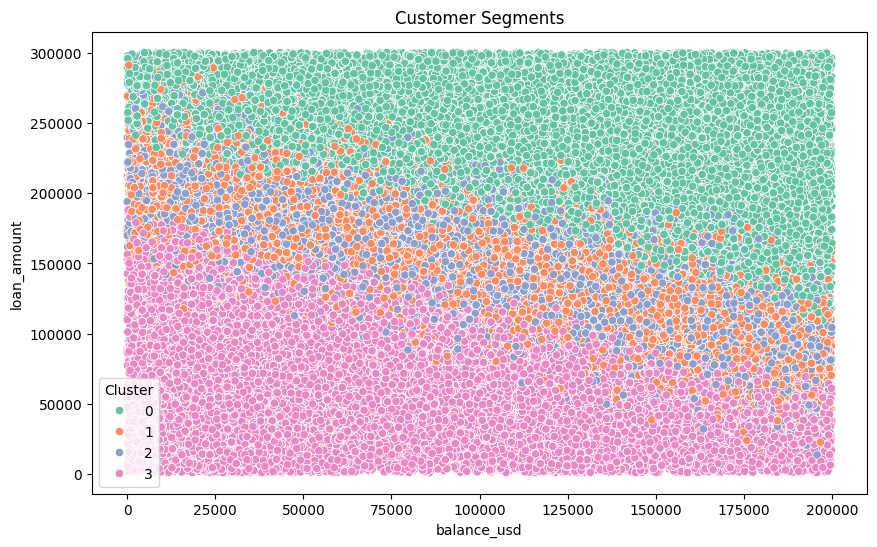

In [326]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master,
    x="balance_usd",
    y="loan_amount",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

In [327]:
master.to_csv(
    "customer_segmentation.csv",
    index=False
)

In [328]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay

In [329]:
X = master[
    [
        "balance_usd",
        "loan_amount",
        "interest_rate",
        "Total_Products",
        "Customer_Value",
        "Loan_Balance_Ratio",
        "Estimated_Interest",
        "Premium_Customer",
        "High_Loan_Customer"
    ]
]

In [330]:
conditions = [
    master['credit_score'] >= 750,
    (master['credit_score'] >= 700) & (master['credit_score'] < 750),
    (master['credit_score'] >= 650) & (master['credit_score'] < 700),
    master['credit_score'] < 650
]
choices = ['Excellent', 'Good', 'Fair', 'Poor']
master['Credit_Category'] = np.select(conditions, choices, default='Unknown')
y = master["Credit_Category"]

In [331]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [332]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [333]:
from sklearn.preprocessing import StandardScaler

lr = LogisticRegression(max_iter=5000) # Increased max_iter

# Impute missing values in X_train
X_train_imputed = X_train.fillna(X_train.median())

# Scale the data
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train_imputed)
X_test_scaled = scaler_lr.transform(X_test.fillna(X_train.median())) # Impute X_test with training median before scaling

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [334]:
lr_pred = lr.predict(X_test_scaled)

In [335]:
accuracy_score(y_test,lr_pred)

0.7202089780706132

In [336]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.66      0.44      0.53      5423
           1       0.00      0.00      0.00      2638
           2       0.00      0.00      0.00      2741
           3       0.73      1.00      0.84     19249

    accuracy                           0.72     30051
   macro avg       0.35      0.36      0.34     30051
weighted avg       0.59      0.72      0.64     30051



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


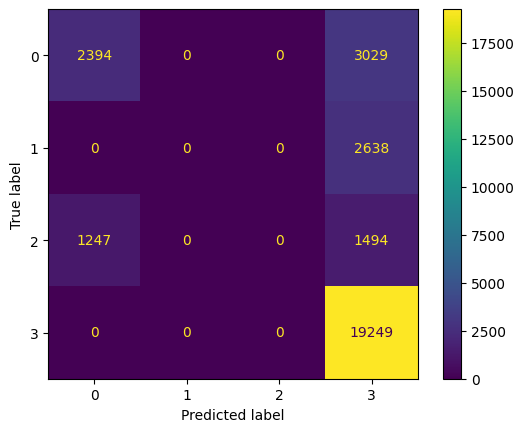

In [337]:
cm = confusion_matrix(y_test,lr_pred)

ConfusionMatrixDisplay(cm).plot()

In [338]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [339]:
dt_pred = dt.predict(X_test)

In [340]:
accuracy_score(y_test,dt_pred)

0.7956473994209843

In [341]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.71      0.68      0.70      5423
           1       0.58      0.57      0.58      2638
           2       0.63      0.62      0.62      2741
           3       0.87      0.88      0.88     19249

    accuracy                           0.80     30051
   macro avg       0.70      0.69      0.69     30051
weighted avg       0.79      0.80      0.79     30051



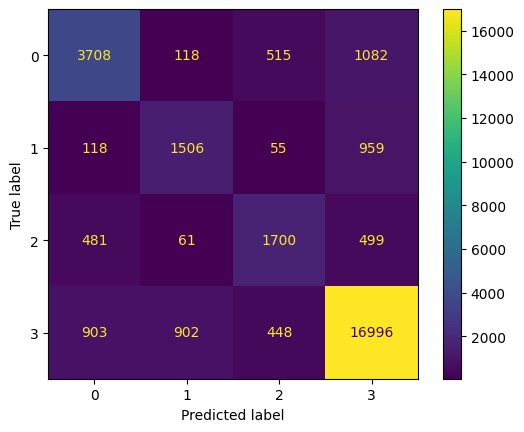

In [342]:
cm = confusion_matrix(y_test,dt_pred)

ConfusionMatrixDisplay(cm).plot()

In [343]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os
import zipfile

# --- Start: Re-creating 'master' DataFrame with all features ---
# Assuming the zip file 'archive (6).zip' is available in the /content/ directory
zip_file_name = "archive (6).zip"
# Check if the data is already extracted to avoid errors if run multiple times
if not os.path.exists("banking_dataset_kaggle/data/csv/customers.csv"):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.')

base_path = "banking_dataset_kaggle/data/csv/"
customers = pd.read_csv(os.path.join(base_path, "customers.csv"))
accounts = pd.read_csv(os.path.join(base_path, "accounts.csv"))
loans = pd.read_csv(os.path.join(base_path, "loans.csv"))
cards = pd.read_csv(os.path.join(base_path, "cards.csv"))

master = customers.merge(accounts, on="customer_id", how="left")
master = master.merge(loans, on="customer_id", how="left")
master = master.merge(cards, on="account_id", how="left")

# Feature Engineering (replicated from earlier cells to ensure all features are present)
master["created_at"] = pd.to_datetime(master["created_at"])
master["open_date"] = pd.to_datetime(master["open_date"])
master["start_date"] = pd.to_datetime(master["start_date"])
master["expiration_date"] = pd.to_datetime(master["expiration_date"])

master["Account_Age_Days"] = (pd.Timestamp.today() - master["open_date"]).dt.days
master["Customer_Tenure_Days"] = (pd.Timestamp.today() - master["created_at"]).dt.days
master["Loan_Duration_Days"] = (pd.Timestamp.today() - master["start_date"]).dt.days
master["Card_Expiry_Days"] = (master["expiration_date"] - pd.Timestamp.today()).dt.days
master["Loan_Balance_Ratio"] = (master["loan_amount"] / master["balance_usd"].replace(0, 1))
master["High_Loan_Customer"] = (master["loan_amount"] > master["loan_amount"].median()).astype(int)
master["Premium_Customer"] = ((master["balance_usd"] > master["balance_usd"].median()) & (master["credit_score"] > 700)).astype(int)
master["Total_Products"] = (master["account_id"].notna().astype(int) + master["loan_id"].notna().astype(int) + master["card_id"].notna().astype(int))
master["Balance_Per_Product"] = (master["balance_usd"] / master["Total_Products"].replace(0, 1))
master["Estimated_Interest"] = (master["loan_amount"] * master["interest_rate"] / 100)
master["Card_Status"] = np.where(master["expiration_date"] < pd.Timestamp.today(), "Expired", "Active")
master["Account_Status"] = np.where(master["balance_usd"] > 0, "Active", "Inactive")
master["Customer_Value"] = (master["balance_usd"] + master["loan_amount"])
# --- End: Re-creating 'master' DataFrame with all features ---


X_master = master[
    [
        "balance_usd",
        "loan_amount",
        "interest_rate",
        "Total_Products",
        "Customer_Value",
        "Loan_Balance_Ratio",
        "Estimated_Interest",
        "Premium_Customer",
        "High_Loan_Customer"
    ]
]

# Handle missing values for X_master, similar to how it was done for Logistic Regression
X_master = X_master.fillna(X_master.median(numeric_only=True))

# Re-create 'Credit_Category' if it was lost or not yet created for this run
conditions = [
    master['credit_score'] >= 750,
    (master['credit_score'] >= 700) & (master['credit_score'] < 750),
    (master['credit_score'] >= 650) & (master['credit_score'] < 700),
    master['credit_score'] < 650
]
choices = ['Excellent', 'Good', 'Fair', 'Poor']
master['Credit_Category'] = np.select(conditions, choices, default='Unknown')

y_master = master["Credit_Category"]

label_encoder_master = LabelEncoder()
y_master = label_encoder_master.fit_transform(y_master)

# Split the data specifically for the master dataset's classification task
X_train_master, X_test_master, y_train_master, y_test_master = train_test_split(
    X_master,
    y_master,
    test_size=0.20,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_master, y_train_master)

RandomForestClassifier(n_estimators=200, random_state=42)

In [344]:
rf_pred = rf.predict(X_test_master)
accuracy_score(y_test_master, rf_pred)

0.8187081960666867

In [345]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.77      0.67      0.72      5423
           1       0.71      0.53      0.61      2638
           2       0.71      0.58      0.64      2741
           3       0.85      0.93      0.89     19249

    accuracy                           0.82     30051
   macro avg       0.76      0.68      0.71     30051
weighted avg       0.81      0.82      0.81     30051



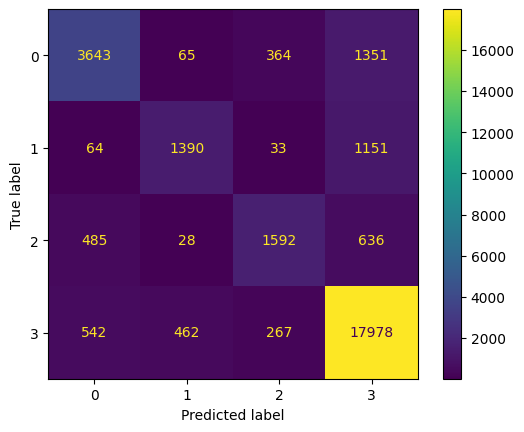

In [346]:
cm = confusion_matrix(y_test,rf_pred)

ConfusionMatrixDisplay(cm).plot()

In [347]:
importance = pd.DataFrame(
    {
        "Feature":X.columns,
        "Importance":rf.feature_importances_
    }
)

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,balance_usd,0.437605
7,Premium_Customer,0.189521
6,Estimated_Interest,0.081051
1,loan_amount,0.079394
2,interest_rate,0.078685
5,Loan_Balance_Ratio,0.062248
4,Customer_Value,0.062008
3,Total_Products,0.008543
8,High_Loan_Customer,0.000945


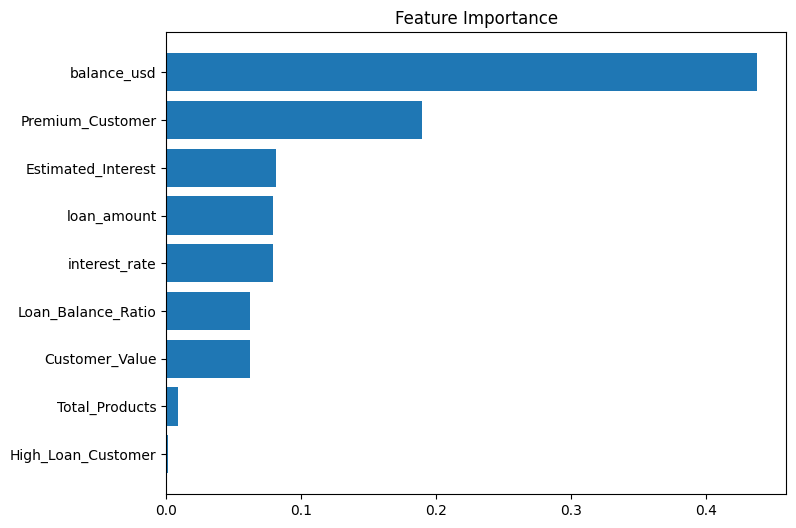

In [348]:
importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [349]:
comparison = pd.DataFrame(
    {
        "Model":[
            "Logistic Regression",
            "Decision Tree",
            "Random Forest"
        ],
        "Accuracy":[
            accuracy_score(y_test,lr_pred),
            accuracy_score(y_test,dt_pred),
            accuracy_score(y_test,rf_pred)
        ]
    }
)

comparison

,Model,Accuracy
0,Logistic Regression,0.720209
1,Decision Tree,0.795647
2,Random Forest,0.818708


In [350]:
import joblib

joblib.dump(
    rf,
    "credit_risk_model.pkl"
)

['credit_risk_model.pkl']

In [351]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

label_encoder.inverse_transform(prediction)

array(['Poor'], dtype=object)

In [352]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [353]:
from google.colab import files

uploaded = files.upload()

Saving archive (8).zip to archive (8) (1).zip


In [354]:
import zipfile

with zipfile.ZipFile("archive (8).zip", "r") as zip_ref:
    zip_ref.extractall()

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [355]:
import zipfile
import os

# Assuming the uploaded file is 'archive (8).zip'
zip_file_name = next(iter(uploaded)) # Get the name of the first (and likely only) uploaded file

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.') # Extract all contents to the current directory

df = pd.read_csv('Loan_Default.csv') # Corrected filename to match the extracted file

In [356]:
df.head()
df.info()
df.shape
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [357]:
df.isnull().sum()

df.duplicated().sum()

df = df.drop_duplicates()

In [358]:
df.shape

(148670, 34)

In [359]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [360]:
df.dtypes

,0
ID,int64
year,int64
loan_limit,object
Gender,object
approv_in_adv,object
loan_type,object
loan_purpose,object
Credit_Worthiness,object
open_credit,object
business_or_commercial,object


In [361]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [362]:
(df.isnull().sum() / len(df)) * 100

,0
ID,0.000000
year,0.000000
loan_limit,2.249277
Gender,0.000000
approv_in_adv,0.610749
loan_type,0.000000
loan_purpose,0.090133
Credit_Worthiness,0.000000
open_credit,0.000000
business_or_commercial,0.000000


In [363]:
df.duplicated().sum()

np.int64(0)

In [364]:
df = df.drop_duplicates()

In [365]:
df.duplicated().sum()

np.int64(0)

In [366]:
df.nunique()

,0
ID,148670
year,1
loan_limit,2
Gender,4
approv_in_adv,2
loan_type,3
loan_purpose,4
Credit_Worthiness,2
open_credit,2
business_or_commercial,2


In [367]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [368]:
df.describe(include="all")

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
count,148670.000000,148670.0,145326,148670,147762,148670,148536,148670,148670,148670,...,148670,148670.000000,148670,148470,148470,133572.000000,148670,148670,148670.000000,124549.000000
unique,NaN,NaN,2,4,2,3,4,2,2,2,...,4,NaN,2,7,2,NaN,4,2,NaN,NaN
top,NaN,NaN,cf,Male,nopre,type1,p3,l1,nopc,nob/c,...,CIB,NaN,CIB,45-54,to_inst,NaN,North,direct,NaN,NaN
freq,NaN,NaN,135348,42346,124621,113173,55934,142344,148114,127908,...,48152,NaN,74392,34720,95814,NaN,74722,148637,NaN,NaN
mean,99224.500000,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,699.789103,NaN,NaN,NaN,72.746457,NaN,NaN,0.246445,37.732932
std,42917.476598,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,115.875857,NaN,NaN,NaN,39.967603,NaN,NaN,0.430942,10.545435
min,24890.000000,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,500.000000,NaN,NaN,NaN,0.967478,NaN,NaN,0.000000,5.000000
25%,62057.250000,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,599.000000,NaN,NaN,NaN,60.474860,NaN,NaN,0.000000,31.000000
50%,99224.500000,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,699.000000,NaN,NaN,NaN,75.135870,NaN,NaN,0.000000,39.000000
75%,136391.750000,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,800.000000,NaN,NaN,NaN,86.184211,NaN,NaN,0.000000,45.000000


In [369]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [370]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

In [371]:
df.select_dtypes(include=["object"]).columns

Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'Neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type'],
      dtype='object')

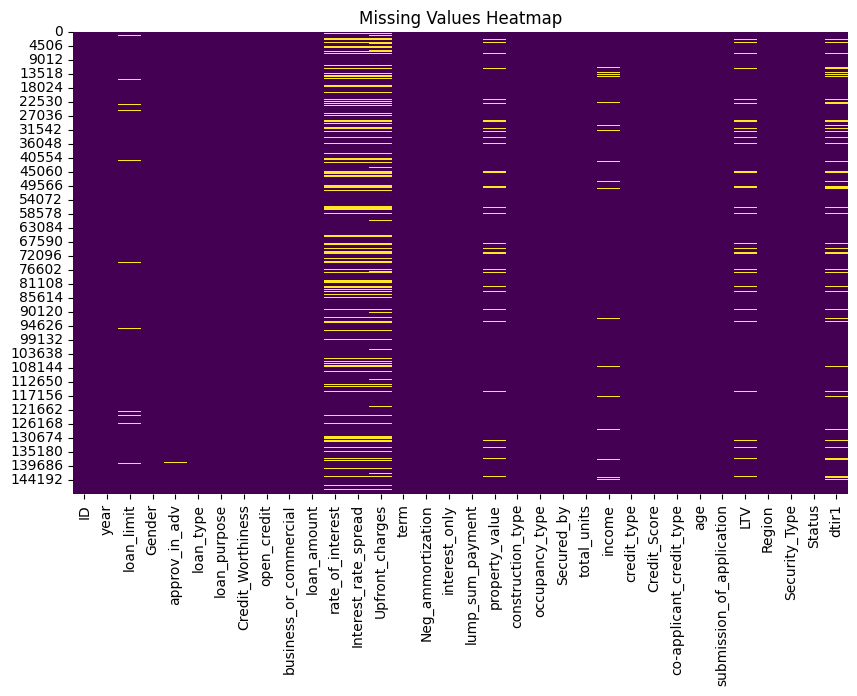

In [372]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [373]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [374]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [375]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,0
Gender,0
approv_in_adv,0
loan_type,0
loan_purpose,0
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


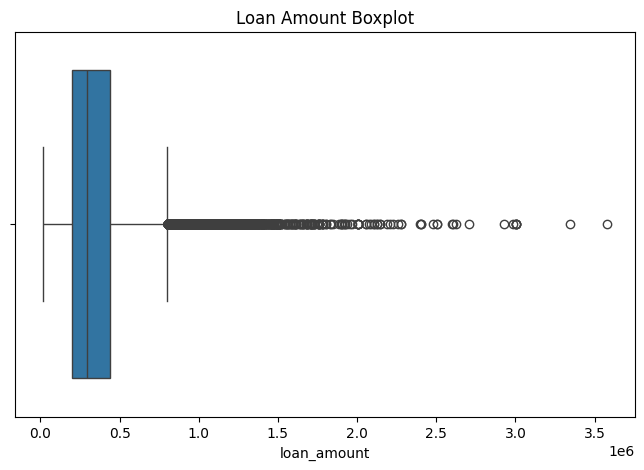

In [376]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["loan_amount"])
plt.title("Loan Amount Boxplot")
plt.show()

In [377]:
df.to_csv("loan_default_cleaned.csv", index=False)

In [378]:
df.head(10)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,75.135870,North,direct,1,39.0
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
7,24897,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,CIB,863,CIB,55-64,to_inst,86.525974,North,direct,0,42.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
9,24899,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,...,CIB,788,EXP,55-64,to_inst,63.444767,south,direct,0,30.0


In [379]:
df.tail(10)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
148660,173550,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,CIB,851,EXP,45-54,not_inst,55.699088,North,direct,0,20.0
148661,173551,2019,cf,Sex Not Available,nopre,type2,p4,l1,nopc,b/c,...,EXP,585,CIB,25-34,to_inst,96.787710,south,direct,1,39.0
148662,173552,2019,cf,Joint,nopre,type1,p4,l1,nopc,nob/c,...,CIB,873,EXP,45-54,not_inst,78.079710,North,direct,0,31.0
148663,173553,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,619,EXP,<25,to_inst,75.135870,North,direct,1,39.0
148664,173554,2019,cf,Joint,nopre,type2,p1,l1,nopc,b/c,...,EXP,859,EXP,65-74,to_inst,99.050633,central,direct,0,45.0
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0
148669,173559,2019,cf,Female,nopre,type1,p3,l1,nopc,nob/c,...,CIB,830,CIB,45-54,not_inst,72.849462,North,direct,0,44.0


In [380]:
df.shape

(148670, 34)

In [381]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,148670.000000,148670.000000,148670.000000,148670.000000,1.486700e+05,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000
mean,99224.500000,2019.0,3.311177e+05,4.031879,0.429024,3057.397919,335.143438,4.897800e+05,6883.647811,699.789103,72.989111,0.246445,37.938508
std,42917.476598,0.0,1.839093e+05,0.488348,0.445907,2797.972965,58.402488,3.420221e+05,6300.067060,115.875857,37.890714,0.430942,9.663417
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.750000,0.181500,1250.000000,360.000000,2.880000e+05,3840.000000,599.000000,63.297872,0.000000,33.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.250000,0.620000,3889.495000,360.000000,5.980000e+05,8280.000000,800.000000,84.722222,0.000000,44.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [382]:
df.corr(numeric_only=True)

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
ID,1.000000,NaN,-0.000566,0.000298,0.001943,-0.004886,-0.004080,0.000833,0.002260,-0.001036,-0.005516,0.001703,-0.007242
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount,-0.000566,NaN,1.000000,-0.122830,-0.309280,0.057451,0.174346,0.686242,0.440715,0.004438,0.036361,-0.036825,0.014935
rate_of_interest,0.000298,NaN,-0.122830,1.000000,0.615149,-0.071066,0.182857,-0.102772,-0.014341,-0.001341,-0.002258,-0.046738,0.029836
Interest_rate_spread,0.001943,NaN,-0.309280,0.615149,1.000000,0.035799,-0.137148,-0.286711,-0.099612,-0.001703,0.036361,-0.049536,0.049866
Upfront_charges,-0.004886,NaN,0.057451,-0.071066,0.035799,1.000000,-0.046542,0.050689,0.027104,-0.001691,-0.032499,-0.095094,-0.013587
term,-0.004080,NaN,0.174346,0.182857,-0.137148,-0.046542,1.000000,0.043050,-0.057391,-0.003167,0.101079,-0.000207,0.106338
property_value,0.000833,NaN,0.686242,-0.102772,-0.286711,0.050689,0.043050,1.000000,0.389435,0.002165,-0.215871,-0.080905,-0.059466
income,0.002260,NaN,0.440715,-0.014341,-0.099612,0.027104,-0.057391,0.389435,1.000000,0.000902,-0.034317,-0.060618,-0.254864
Credit_Score,-0.001036,NaN,0.004438,-0.001341,-0.001703,-0.001691,-0.003167,0.002165,0.000902,1.000000,-0.005208,0.004004,-0.000294


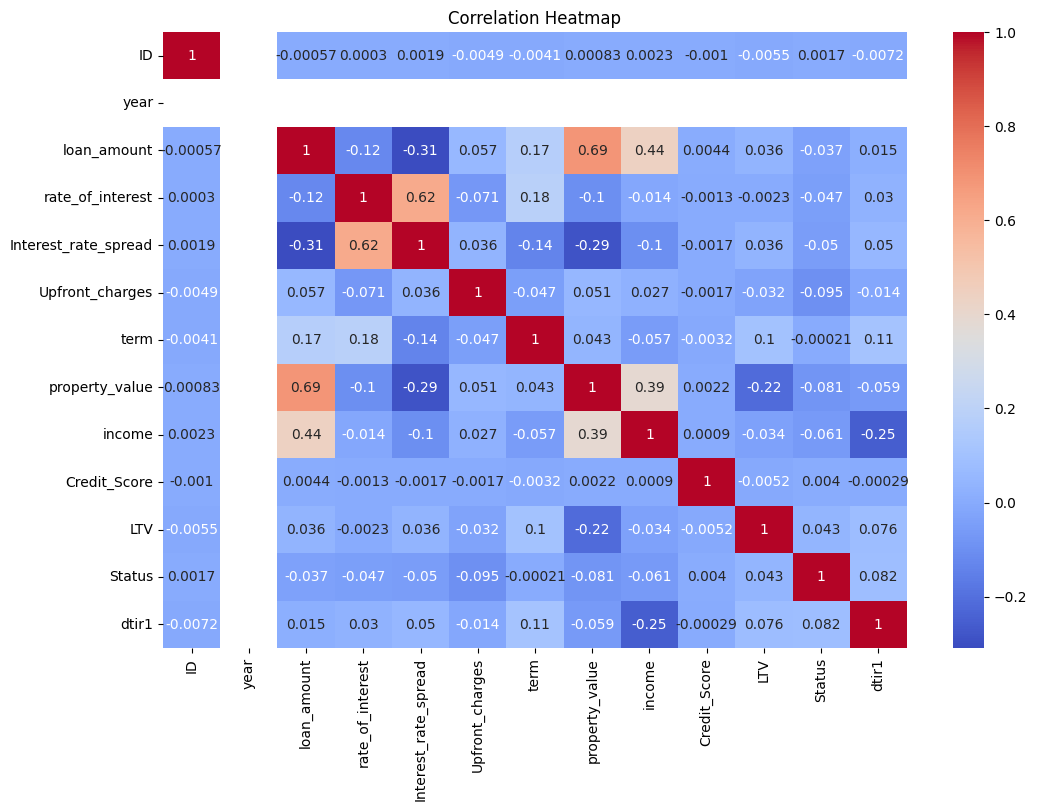

In [383]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

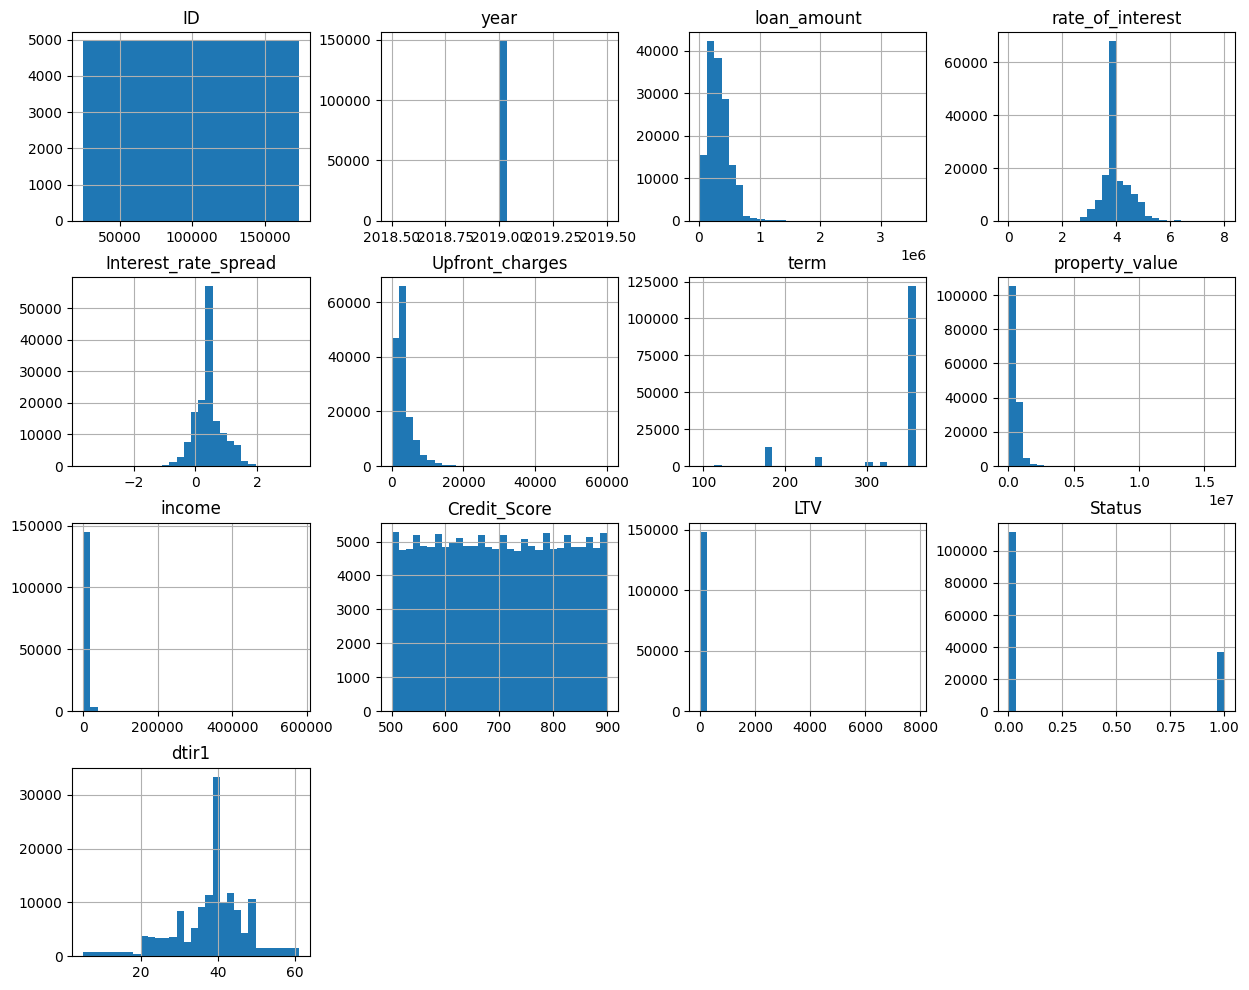

In [384]:
df.hist(figsize=(15,12), bins=30)
plt.show()

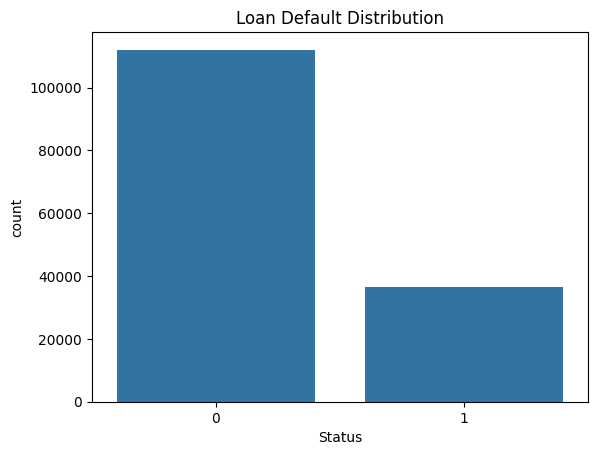

In [385]:
sns.countplot(x="Status", data=df)

plt.title("Loan Default Distribution")

plt.show()

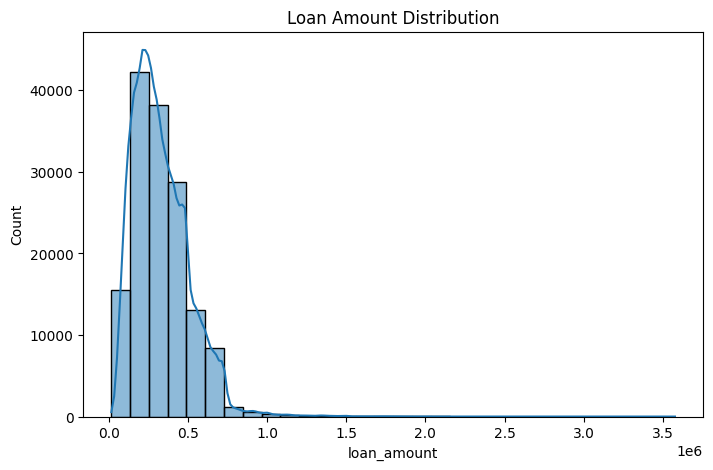

In [386]:
plt.figure(figsize=(8,5))

sns.histplot(df["loan_amount"], bins=30, kde=True)

plt.title("Loan Amount Distribution")

plt.show()

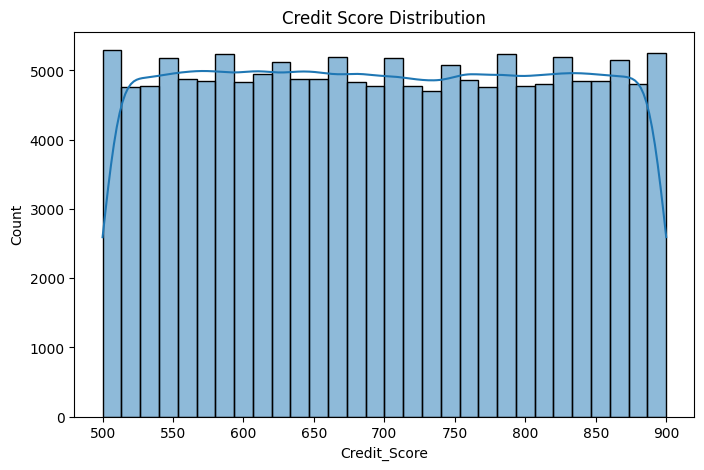

In [387]:
plt.figure(figsize=(8,5))

sns.histplot(df["Credit_Score"], bins=30, kde=True)

plt.title("Credit Score Distribution")

plt.show()

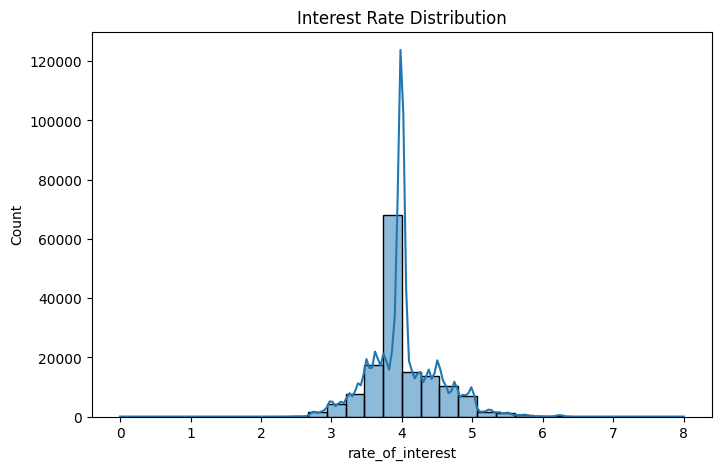

In [388]:
plt.figure(figsize=(8,5))

sns.histplot(df["rate_of_interest"], bins=30, kde=True)

plt.title("Interest Rate Distribution")

plt.show()

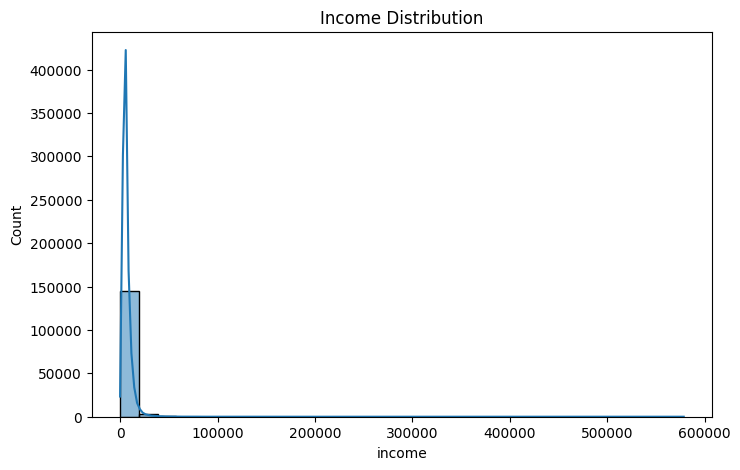

In [389]:
plt.figure(figsize=(8,5))

sns.histplot(df["income"], bins=30, kde=True)

plt.title("Income Distribution")

plt.show()

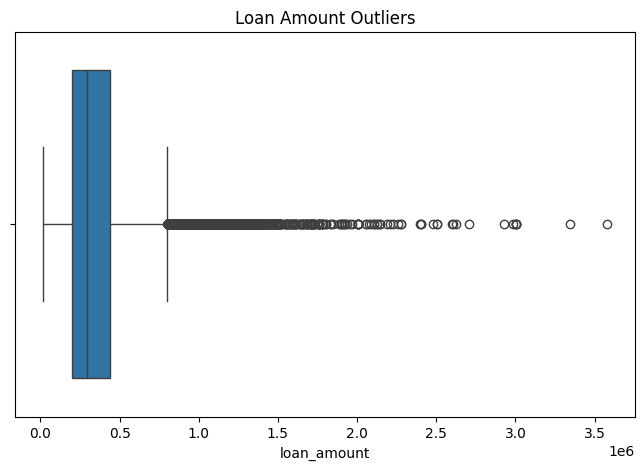

In [390]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["loan_amount"])

plt.title("Loan Amount Outliers")

plt.show()

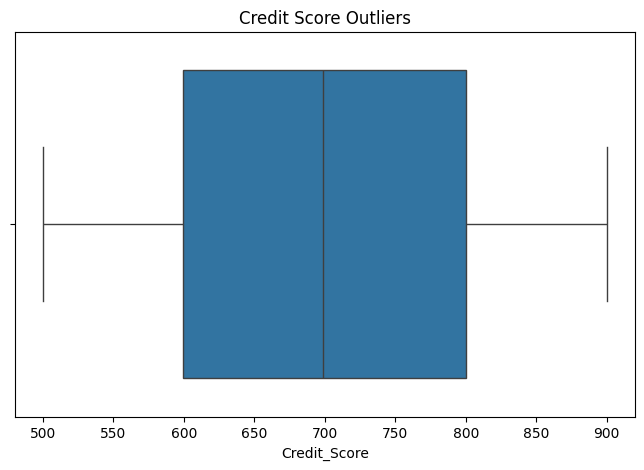

In [391]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Credit_Score"])

plt.title("Credit Score Outliers")

plt.show()

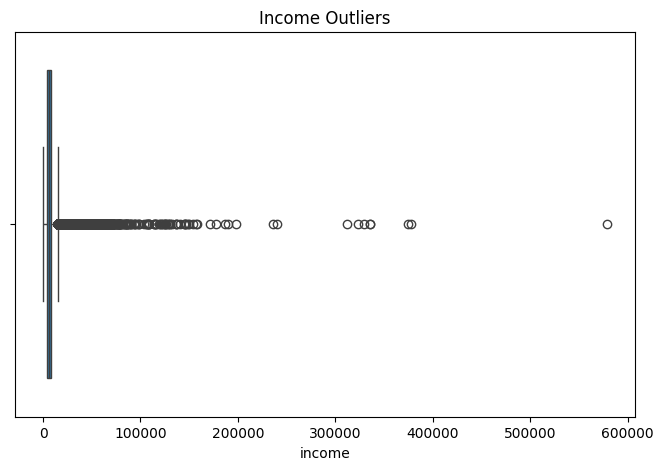

In [392]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["income"])

plt.title("Income Outliers")

plt.show()

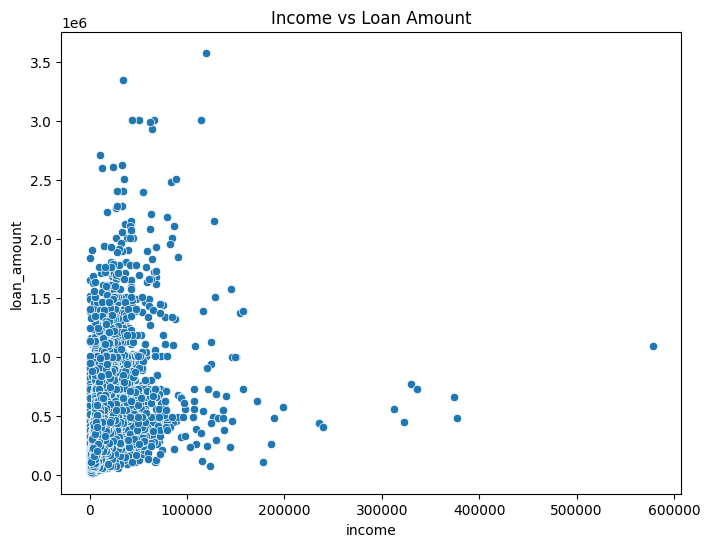

In [393]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="income",
    y="loan_amount"
)

plt.title("Income vs Loan Amount")

plt.show()

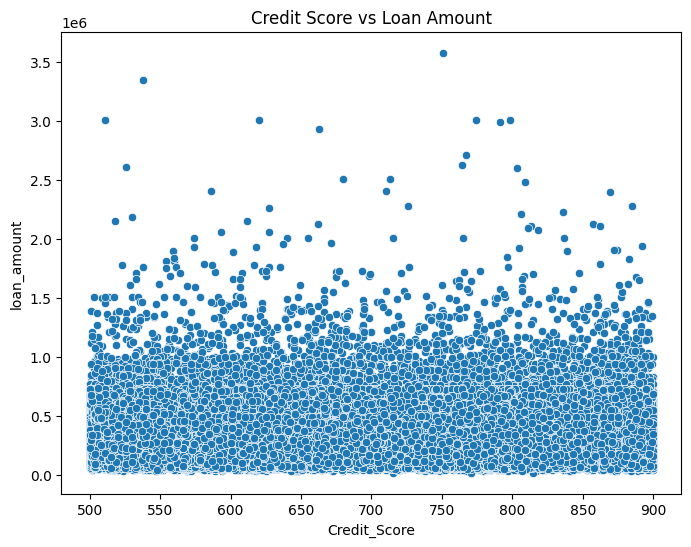

In [394]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Credit_Score",
    y="loan_amount"
)

plt.title("Credit Score vs Loan Amount")

plt.show()

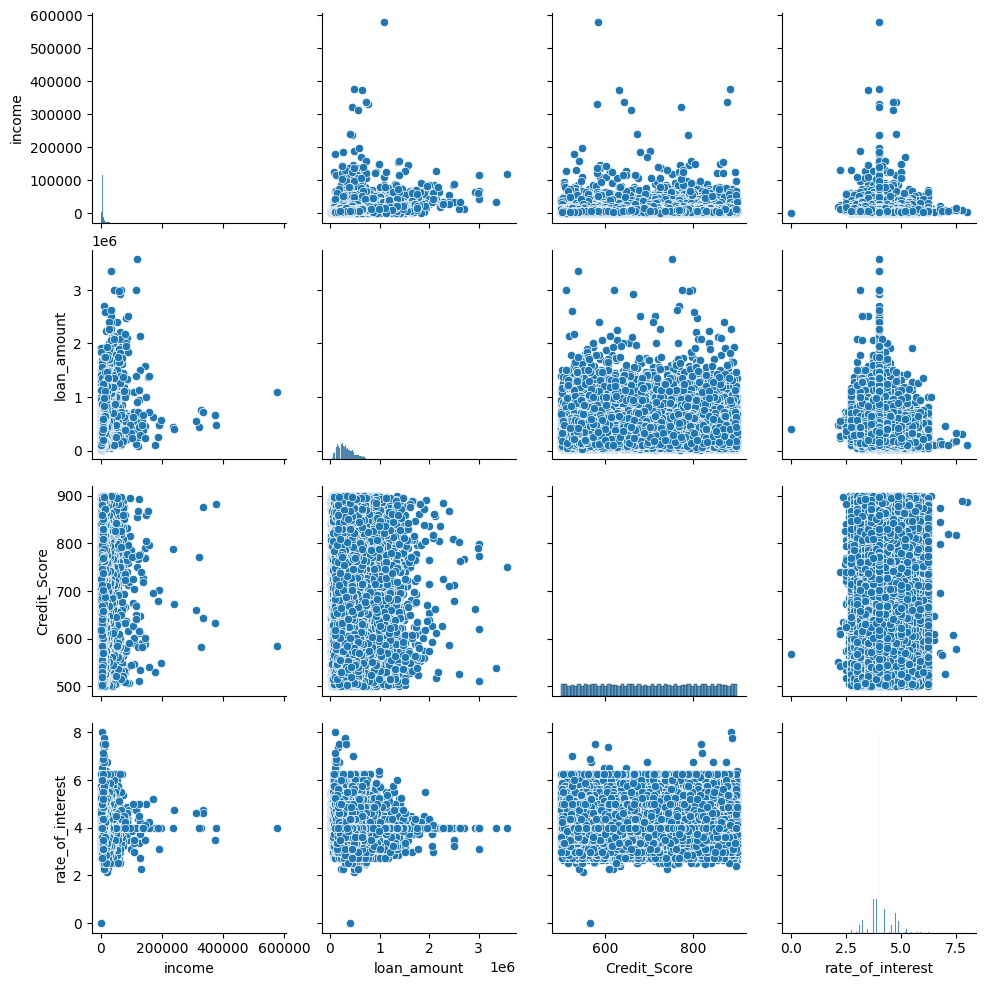

In [395]:
sns.pairplot(
    df[
        [
            "income",
            "loan_amount",
            "Credit_Score",
            "rate_of_interest"
        ]
    ]
)

plt.show()

In [396]:
df["Status"].value_counts(normalize=True) * 100

,proportion
Status,
0,75.355485
1,24.644515


In [397]:
df.columns.tolist()

['ID',
 'year',
 'loan_limit',
 'Gender',
 'approv_in_adv',
 'loan_type',
 'loan_purpose',
 'Credit_Worthiness',
 'open_credit',
 'business_or_commercial',
 'loan_amount',
 'rate_of_interest',
 'Interest_rate_spread',
 'Upfront_charges',
 'term',
 'Neg_ammortization',
 'interest_only',
 'lump_sum_payment',
 'property_value',
 'construction_type',
 'occupancy_type',
 'Secured_by',
 'total_units',
 'income',
 'credit_type',
 'Credit_Score',
 'co-applicant_credit_type',
 'age',
 'submission_of_application',
 'LTV',
 'Region',
 'Security_Type',
 'Status',
 'dtir1']

In [398]:
df["Loan_Property_Ratio"] = df["loan_amount"] / df["property_value"]

In [399]:
df["Income_Loan_Ratio"] = df["income"] / df["loan_amount"]

In [400]:
df["High_Loan"] = (
    df["loan_amount"] >
    df["loan_amount"].median()
).astype(int)

In [401]:
df["High_Income"] = (
    df["income"] >
    df["income"].median()
).astype(int)

In [402]:
df["Credit_Category"] = pd.cut(
    df["Credit_Score"],
    bins=[0,580,670,740,800,900],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

In [403]:
df["Interest_Category"] = pd.cut(
    df["rate_of_interest"],
    bins=[0,5,8,12,20],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [404]:
df["Property_Category"] = pd.qcut(
    df["property_value"],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [405]:
df.to_csv(
    "loan_default_feature_engineered.csv",
    index=False
)

In [406]:
X = df[
[
    "loan_amount",
    "income",
    "Credit_Score",
    "rate_of_interest",
    "property_value",
    "LTV",
    "Loan_Property_Ratio",
    "Income_Loan_Ratio",
    "High_Loan",
    "High_Income"
]
]

In [407]:
y = df["Status"]

In [408]:
X.isnull().sum()

,0
loan_amount,0
income,0
Credit_Score,0
rate_of_interest,0
property_value,0
LTV,0
Loan_Property_Ratio,0
Income_Loan_Ratio,0
High_Loan,0
High_Income,0


In [409]:
X = X.fillna(X.median(numeric_only=True))

In [410]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [411]:
X.shape

(148670, 10)

In [412]:
y.shape

(148670,)

In [413]:
X.head()

,loan_amount,income,Credit_Score,rate_of_interest,property_value,LTV,Loan_Property_Ratio,Income_Loan_Ratio,High_Loan,High_Income
0,116500,1740.0,758,3.99,118000.0,98.728814,0.987288,0.014936,0,0
1,206500,4980.0,552,3.99,418000.0,75.135870,0.494019,0.024116,0,0
2,406500,9480.0,834,4.56,508000.0,80.019685,0.800197,0.023321,1,1
3,456500,11880.0,587,4.25,658000.0,69.376900,0.693769,0.026024,1,1
4,696500,10440.0,602,4.00,758000.0,91.886544,0.918865,0.014989,1,1


In [414]:
pd.Series(y).value_counts()

,count
0,112031
1,36639


In [415]:
X.head()

,loan_amount,income,Credit_Score,rate_of_interest,property_value,LTV,Loan_Property_Ratio,Income_Loan_Ratio,High_Loan,High_Income
0,116500,1740.0,758,3.99,118000.0,98.728814,0.987288,0.014936,0,0
1,206500,4980.0,552,3.99,418000.0,75.135870,0.494019,0.024116,0,0
2,406500,9480.0,834,4.56,508000.0,80.019685,0.800197,0.023321,1,1
3,456500,11880.0,587,4.25,658000.0,69.376900,0.693769,0.026024,1,1
4,696500,10440.0,602,4.00,758000.0,91.886544,0.918865,0.014989,1,1


In [416]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [417]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [418]:
X_train.shape

(118936, 10)

In [419]:
X_test.shape

(29734, 10)

In [420]:
y_train.shape

(118936,)

In [421]:
y_test.shape

(29734,)

In [422]:
X_train.head()

,loan_amount,income,Credit_Score,rate_of_interest,property_value,LTV,Loan_Property_Ratio,Income_Loan_Ratio,High_Loan,High_Income
141039,206500,6360.0,676,2.875,758000.0,27.242744,0.272427,0.030799,0,1
121276,466500,5100.0,675,4.250,668000.0,69.835329,0.698353,0.010932,1,0
11214,326500,2760.0,593,3.990,708000.0,46.115819,0.461158,0.008453,1,0
129659,256500,12300.0,894,3.875,288000.0,89.062500,0.890625,0.047953,0,1
13370,166500,2100.0,896,4.500,218000.0,76.376147,0.763761,0.012613,0,0


In [423]:
y_train[:5]

array([0, 0, 1, 0, 0])

In [424]:
scaler = StandardScaler()

In [425]:
X_train_scaled = scaler.fit_transform(X_train)

In [426]:
X_test_scaled = scaler.transform(X_test)

In [427]:
X_train_scaled.shape

(118936, 10)

In [428]:
X_test_scaled.shape

(29734, 10)

In [429]:
X_train_scaled[:5]

array([[-0.67965894, -0.08222531, -0.20565162, -2.36445142,  0.78631746,
        -1.119244  , -1.05602066,  0.39887426, -0.98877957,  1.07655892],
       [ 0.73982819, -0.27886807, -0.214287  ,  0.44681625,  0.52240708,
        -0.07729771, -0.08121961, -0.64265257,  1.01134776, -0.92888553],
       [-0.02451103, -0.64406176, -0.92238754, -0.08476891,  0.63970058,
        -0.65755024, -0.62407944, -0.77262658,  1.01134776, -0.92888553],
       [-0.40668065,  0.84480482,  1.67685957, -0.31989311, -0.59188121,
         0.39305832,  0.35882568,  1.29820195, -0.98877957,  1.07655892],
       [-0.89804158, -0.74706511,  1.69413032,  0.95795583, -0.79714484,
         0.0827109 ,  0.06847771, -0.55456948, -0.98877957, -0.92888553]])

In [430]:
import joblib

joblib.dump(scaler, "loan_scaler.pkl")

['loan_scaler.pkl']

In [431]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [432]:
log_model = LogisticRegression(random_state=42)

In [433]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [434]:
y_pred_log = log_model.predict(X_test_scaled)

In [435]:
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", round(log_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 75.51 %


In [436]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86     22406
           1       0.98      0.01      0.01      7328

    accuracy                           0.76     29734
   macro avg       0.87      0.50      0.44     29734
weighted avg       0.81      0.76      0.65     29734



In [437]:
cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[22405     1]
 [ 7280    48]]


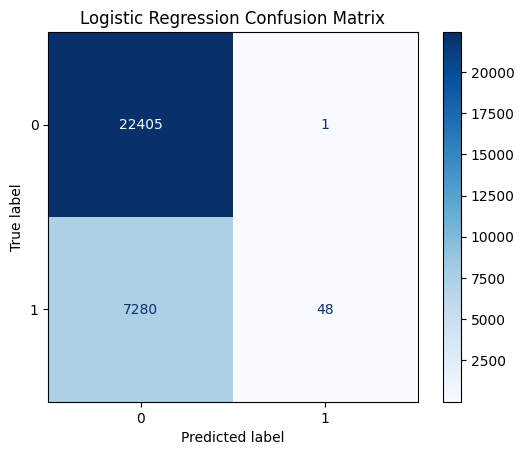

In [438]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [439]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_log
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [440]:
(correct_predictions) = (y_test == y_pred_log).sum()

print("Correct Predictions:", correct_predictions)

Correct Predictions: 22453


In [441]:
incorrect_predictions = (y_test != y_pred_log).sum()

print("Incorrect Predictions:", incorrect_predictions)

Incorrect Predictions: 7281


In [442]:
log_model.predict_proba(X_test_scaled)

array([[0.84638015, 0.15361985],
       [0.76978477, 0.23021523],
       [0.72642322, 0.27357678],
       ...,
       [0.76878402, 0.23121598],
       [0.81217891, 0.18782109],
       [0.72952277, 0.27047723]])

In [443]:
log_model.predict_proba(X_test_scaled)[:10]

array([[0.84638015, 0.15361985],
       [0.76978477, 0.23021523],
       [0.72642322, 0.27357678],
       [0.80732934, 0.19267066],
       [0.71712259, 0.28287741],
       [0.70069755, 0.29930245],
       [0.72983844, 0.27016156],
       [0.81770948, 0.18229052],
       [0.81355835, 0.18644165],
       [0.76949654, 0.23050346]])

In [444]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
6,Loan_Property_Ratio,0.318522
0,loan_amount,0.199692
7,Income_Loan_Ratio,0.076894
2,Credit_Score,0.007610
5,LTV,-0.078419
9,High_Income,-0.126563
3,rate_of_interest,-0.128861
4,property_value,-0.134082
8,High_Loan,-0.149654
1,income,-0.198253


In [445]:
import joblib

joblib.dump(
    log_model,
    "logistic_regression_model.pkl"
)

['logistic_regression_model.pkl']

In [446]:
sample = X_test_scaled[:1]

prediction = log_model.predict(sample)

print("Predicted Status:", prediction)

Predicted Status: [0]


In [447]:
from sklearn.tree import DecisionTreeClassifier

In [448]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

In [449]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [450]:
y_pred_dt = dt_model.predict(X_test)

In [451]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 90.94 %


In [452]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94     22406
           1       0.80      0.84      0.82      7328

    accuracy                           0.91     29734
   macro avg       0.87      0.89      0.88     29734
weighted avg       0.91      0.91      0.91     29734



In [453]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[20883  1523]
 [ 1171  6157]]


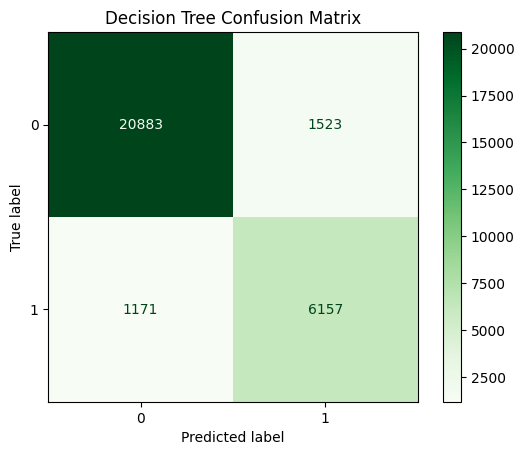

In [454]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)

disp.plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [455]:
comparison_dt = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_dt
})

comparison_dt.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,1


In [456]:
correct_dt = (y_test == y_pred_dt).sum()

print("Correct Predictions:", correct_dt)

Correct Predictions: 27040


In [457]:
incorrect_dt = (y_test != y_pred_dt).sum()

print("Incorrect Predictions:", incorrect_dt)

Incorrect Predictions: 2694


In [458]:
incorrect_dt = (y_test != y_pred_dt).sum()

print("Incorrect Predictions:", incorrect_dt)

Incorrect Predictions: 2694


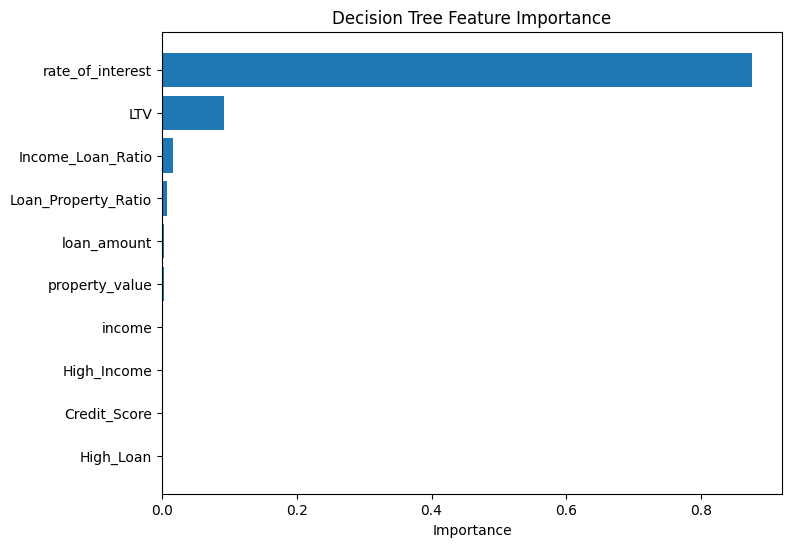

In [459]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Decision Tree Feature Importance")

plt.xlabel("Importance")

plt.show()

In [460]:
import joblib

joblib.dump(
    dt_model,
    "decision_tree_model.pkl"
)

['decision_tree_model.pkl']

In [461]:
sample = X_test.iloc[[0]]

prediction = dt_model.predict(sample)

print("Predicted Status:", prediction)

Predicted Status: [0]


In [462]:
print("Tree Depth:", dt_model.get_depth())

Tree Depth: 6


In [463]:
print("Number of Leaves:", dt_model.get_n_leaves())

Number of Leaves: 37


In [464]:
from sklearn.ensemble import RandomForestClassifier

In [465]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [466]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [467]:
y_pred_rf = rf_model.predict(X_test)

In [468]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 90.2 %


In [469]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93     22406
           1       0.79      0.81      0.80      7328

    accuracy                           0.90     29734
   macro avg       0.87      0.87      0.87     29734
weighted avg       0.90      0.90      0.90     29734



In [470]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[20866  1540]
 [ 1374  5954]]


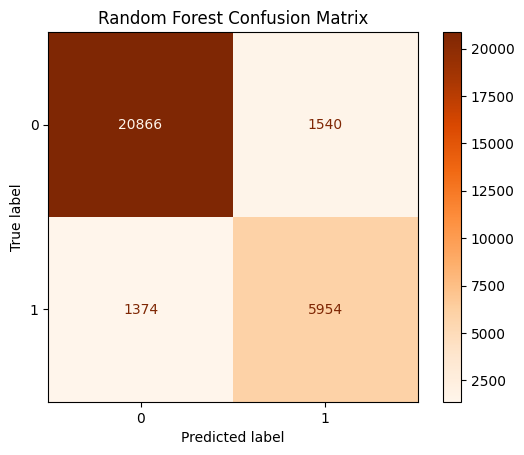

In [471]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

disp.plot(cmap="Oranges")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [472]:
comparison_rf = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

comparison_rf.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [473]:
correct_rf = (y_test == y_pred_rf).sum()

print("Correct Predictions:", correct_rf)

Correct Predictions: 26820


In [474]:
incorrect_rf = (y_test != y_pred_rf).sum()

print("Incorrect Predictions:", incorrect_rf)

Incorrect Predictions: 2914


In [475]:
rf_model.predict_proba(X_test)

array([[0.99, 0.01],
       [1.  , 0.  ],
       [1.  , 0.  ],
       ...,
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.98, 0.02]])

In [476]:
rf_model.predict_proba(X_test)[:10]

array([[0.99, 0.01],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.98, 0.02],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.51, 0.49]])

In [477]:
feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,rate_of_interest,0.424211
4,property_value,0.130407
5,LTV,0.109805
6,Loan_Property_Ratio,0.091190
7,Income_Loan_Ratio,0.075923
2,Credit_Score,0.071948
1,income,0.062097
0,loan_amount,0.029335
9,High_Income,0.002954
8,High_Loan,0.002130


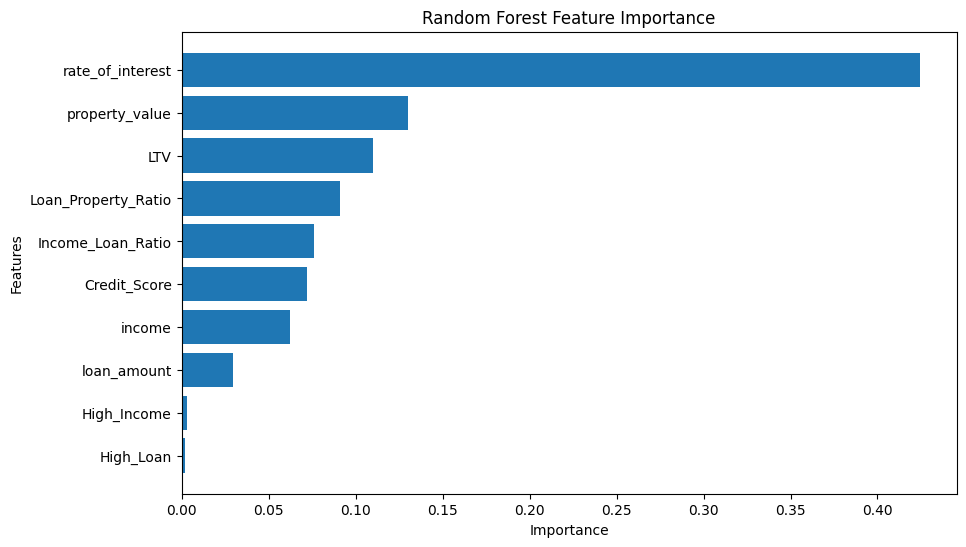

In [478]:
feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_rf["Feature"],
    feature_importance_rf["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Random Forest Feature Importance")

plt.show()

In [479]:
print("Number of Trees:", len(rf_model.estimators_))

Number of Trees: 100


In [480]:
import joblib

joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

['random_forest_model.pkl']

In [481]:
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)

print("Predicted Status:", prediction)

Predicted Status: [0]


In [482]:
probability = rf_model.predict_proba(sample)

print(probability)

[[0.99 0.01]]


In [483]:
len(rf_model.estimators_)

100

In [484]:
X_test.shape

(29734, 10)

In [485]:
type(X_test)

pandas.core.frame.DataFrame

In [486]:
rf_pred = rf_model.predict(X_test)

In [487]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 90.2 %


In [488]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93     22406
           1       0.79      0.81      0.80      7328

    accuracy                           0.90     29734
   macro avg       0.87      0.87      0.87     29734
weighted avg       0.90      0.90      0.90     29734



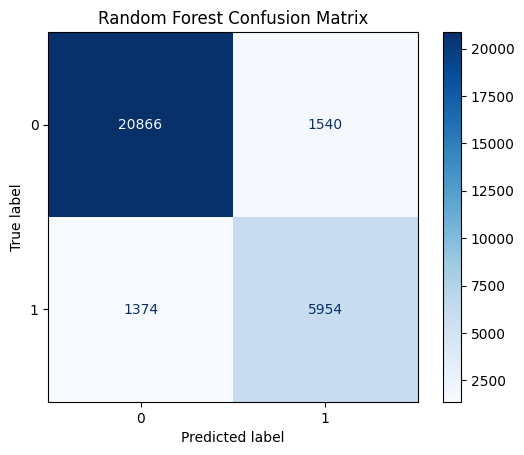

In [489]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [490]:
import pandas as pd
import matplotlib.pyplot as plt

In [491]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.755129
1,Decision Tree,0.909397
2,Random Forest,0.901998


In [492]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Decision Tree,0.909397
2,Random Forest,0.901998
0,Logistic Regression,0.755129


In [493]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

best_model

,1
Model,Decision Tree
Accuracy,0.909397


In [494]:
print("Best Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"]*100,2), "%")

Best Model : Decision Tree
Accuracy : 90.94 %


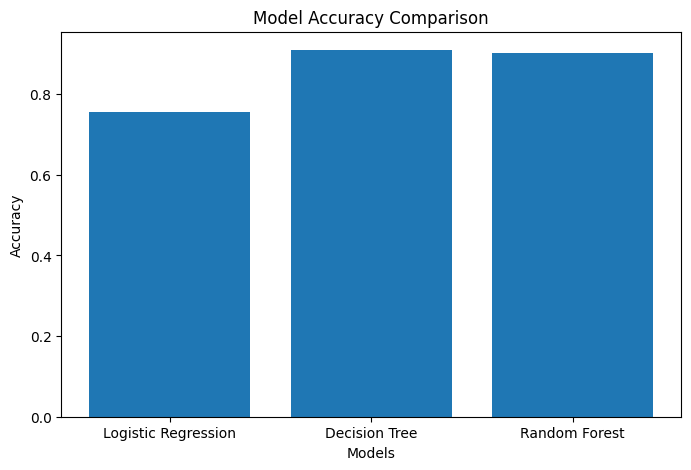

In [495]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

In [496]:
comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.755129,75.512881
1,Decision Tree,0.909397,90.939665
2,Random Forest,0.901998,90.199771


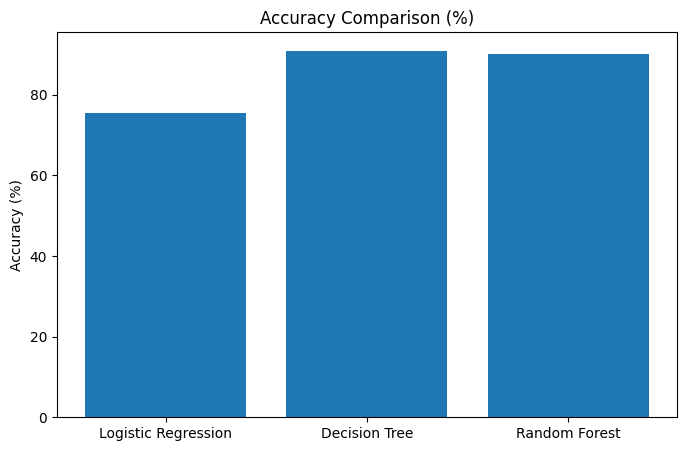

In [497]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.title("Accuracy Comparison (%)")

plt.ylabel("Accuracy (%)")

plt.show()

In [498]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

In [499]:
from sklearn.metrics import precision_score

precision = [
    precision_score(y_test, y_pred_log, average="weighted"),
    precision_score(y_test, y_pred_dt, average="weighted"),
    precision_score(y_test, y_pred_rf, average="weighted")
]

comparison["Precision"] = precision

comparison

,Model,Accuracy,Accuracy (%),Precision
0,Logistic Regression,0.755129,75.512881,0.810169
1,Decision Tree,0.909397,90.939665,0.911116
2,Random Forest,0.901998,90.199771,0.902800


In [500]:
from sklearn.metrics import recall_score

recall = [
    recall_score(y_test, y_pred_log, average="weighted"),
    recall_score(y_test, y_pred_dt, average="weighted"),
    recall_score(y_test, y_pred_rf, average="weighted")
]

comparison["Recall"] = recall

comparison

,Model,Accuracy,Accuracy (%),Precision,Recall
0,Logistic Regression,0.755129,75.512881,0.810169,0.755129
1,Decision Tree,0.909397,90.939665,0.911116,0.909397
2,Random Forest,0.901998,90.199771,0.902800,0.901998


In [501]:
from sklearn.metrics import f1_score

f1 = [
    f1_score(y_test, y_pred_log, average="weighted"),
    f1_score(y_test, y_pred_dt, average="weighted"),
    f1_score(y_test, y_pred_rf, average="weighted")
]

comparison["F1 Score"] = f1

comparison

,Model,Accuracy,Accuracy (%),Precision,Recall,F1 Score
0,Logistic Regression,0.755129,75.512881,0.810169,0.755129,0.651428
1,Decision Tree,0.909397,90.939665,0.911116,0.909397,0.910100
2,Random Forest,0.901998,90.199771,0.902800,0.901998,0.902364


In [502]:
comparison

,Model,Accuracy,Accuracy (%),Precision,Recall,F1 Score
0,Logistic Regression,0.755129,75.512881,0.810169,0.755129,0.651428
1,Decision Tree,0.909397,90.939665,0.911116,0.909397,0.910100
2,Random Forest,0.901998,90.199771,0.902800,0.901998,0.902364


In [503]:
comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

In [504]:
best_model_name = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

print("The Best Performing Model is:", best_model_name)

The Best Performing Model is: Decision Tree


In [505]:
import joblib

In [506]:
joblib.dump(
    rf_model,
    "best_loan_default_model.pkl"
)

['best_loan_default_model.pkl']

In [507]:
joblib.dump(
    scaler,
    "loan_scaler.pkl"
)

['loan_scaler.pkl']

In [508]:
loaded_model = joblib.load(
    "best_loan_default_model.pkl"
)

In [509]:
sample_prediction = loaded_model.predict(
    X_test.iloc[[0]]
)

print("Predicted Status:", sample_prediction)

Predicted Status: [0]


In [510]:
sample_probability = loaded_model.predict_proba(
    X_test.iloc[[0]]
)

print(sample_probability)

[[0.99 0.01]]


In [511]:
sample_probability = loaded_model.predict_proba(
    X_test.iloc[[0]]
)

print(sample_probability)

[[0.99 0.01]]


In [512]:
print("Actual Status :", y_test.iloc[0] if hasattr(y_test, "iloc") else y_test[0])

print("Predicted Status :", sample_prediction[0])

Actual Status : 0
Predicted Status : 0


In [513]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,rate_of_interest,0.424211
4,property_value,0.130407
5,LTV,0.109805
6,Loan_Property_Ratio,0.091190
7,Income_Loan_Ratio,0.075923
2,Credit_Score,0.071948
1,income,0.062097
0,loan_amount,0.029335
9,High_Income,0.002954
8,High_Loan,0.002130


In [514]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [515]:
feature_importance.head(5)

,Feature,Importance
3,rate_of_interest,0.424211
4,property_value,0.130407
5,LTV,0.109805
6,Loan_Property_Ratio,0.091190
7,Income_Loan_Ratio,0.075923


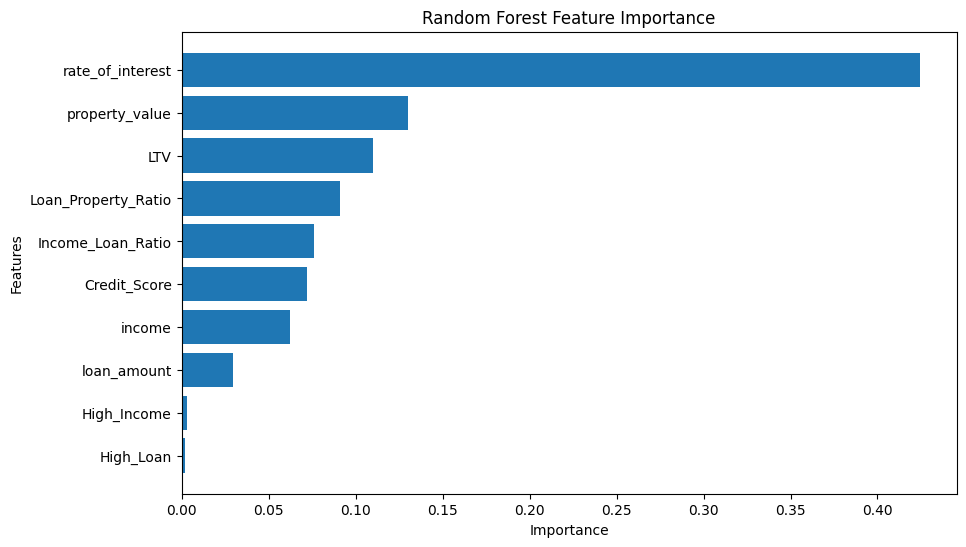

In [516]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [517]:
import os

os.listdir()

['.config',
 'archive (6).zip',
 'Business_Insights.csv',
 'Feature_Importance.csv',
 'customer_segmentation.csv',
 'archive (8).zip',
 'loan_default_cleaned.csv',
 'loan_scaler.pkl',
 'archive (8) (1).zip',
 'loan_default_feature_engineered.csv',
 'feature_importance.csv',
 'business_insights.csv',
 'banking_master_dataset.csv',
 'archive (6) (1).zip',
 'final_model_comparison.csv',
 'credit_risk_model.pkl',
 'best_loan_default_model.pkl',
 'Final_Loan_Default_Model.pkl',
 'Final_Loan_Default_Dataset.csv',
 'logistic_regression_model.pkl',
 'random_forest_model.pkl',
 'Model_Comparison.csv',
 'banking_master_dataset_feature_engineered.csv',
 'model_comparison.csv',
 'Loan_Default.csv',
 'banking_dataset_kaggle',
 'decision_tree_model.pkl',
 'sample_data']

In [518]:
feature_importance.head(10)

,Feature,Importance
3,rate_of_interest,0.424211
4,property_value,0.130407
5,LTV,0.109805
6,Loan_Property_Ratio,0.091190
7,Income_Loan_Ratio,0.075923
2,Credit_Score,0.071948
1,income,0.062097
0,loan_amount,0.029335
9,High_Income,0.002954
8,High_Loan,0.002130


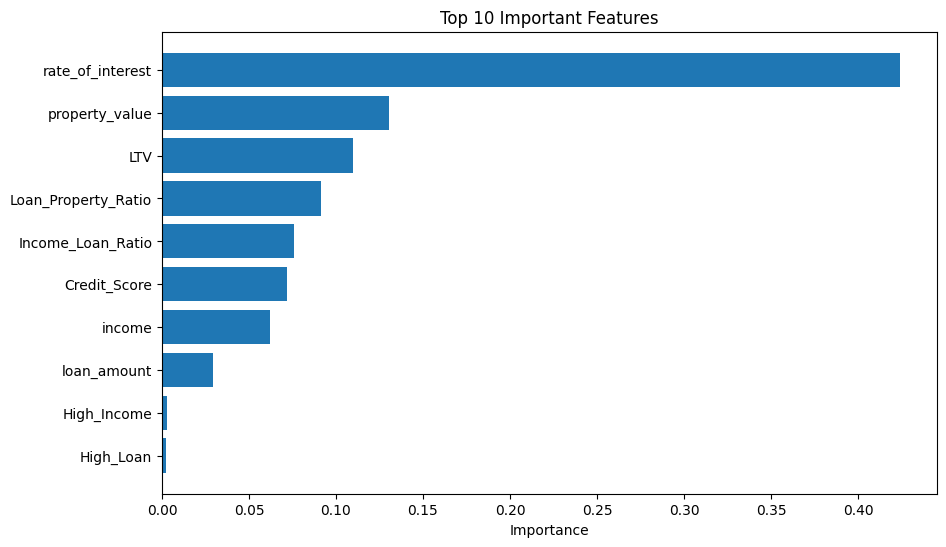

In [519]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [520]:
df["Status"].value_counts()

,count
Status,
0,112031
1,36639


In [521]:
round(df["Status"].value_counts(normalize=True)*100,2)

,proportion
Status,
0,75.36
1,24.64


In [522]:
df.groupby("Status")["loan_amount"].mean()

,loan_amount
Status,
0,334990.774875
1,319275.184912


In [523]:
df.groupby("Status")["income"].mean()

,income
Status,
0,7102.046041
1,6215.851961


In [524]:
df.groupby("Status")["Credit_Score"].mean()

,Credit_Score
Status,
0,699.523793
1,700.600344


In [525]:
df.groupby("Status")["rate_of_interest"].mean()

,rate_of_interest
Status,
0,4.044931
1,3.991968


In [526]:
df.groupby("Status")["property_value"].mean()

,property_value
Status,
0,505604.502325
1,441393.378640


In [527]:
df.groupby("Status")["LTV"].mean()

,LTV
Status,
0,72.064812
1,75.815339


In [528]:
df["loan_type"].value_counts()

,count
loan_type,
type1,113173
type2,20762
type3,14735


In [529]:
df["Credit_Worthiness"].value_counts()

,count
Credit_Worthiness,
l1,142344
l2,6326


In [530]:
df["Gender"].value_counts()

,count
Gender,
Male,42346
Joint,41399
Sex Not Available,37659
Female,27266


In [531]:
df["occupancy_type"].value_counts()

,count
occupancy_type,
pr,138201
ir,7340
sr,3129


In [532]:
df["Property_Category"].value_counts()

,count
Property_Category,
Low,50295
High,49498
Medium,48877


In [533]:
df[
[
    "loan_amount",
    "income",
    "Credit_Score",
    "property_value",
    "rate_of_interest",
    "LTV"
]
].corr()

,loan_amount,income,Credit_Score,property_value,rate_of_interest,LTV
loan_amount,1.000000,0.440715,0.004438,0.686242,-0.122830,0.036361
income,0.440715,1.000000,0.000902,0.389435,-0.014341,-0.034317
Credit_Score,0.004438,0.000902,1.000000,0.002165,-0.001341,-0.005208
property_value,0.686242,0.389435,0.002165,1.000000,-0.102772,-0.215871
rate_of_interest,-0.122830,-0.014341,-0.001341,-0.102772,1.000000,-0.002258
LTV,0.036361,-0.034317,-0.005208,-0.215871,-0.002258,1.000000


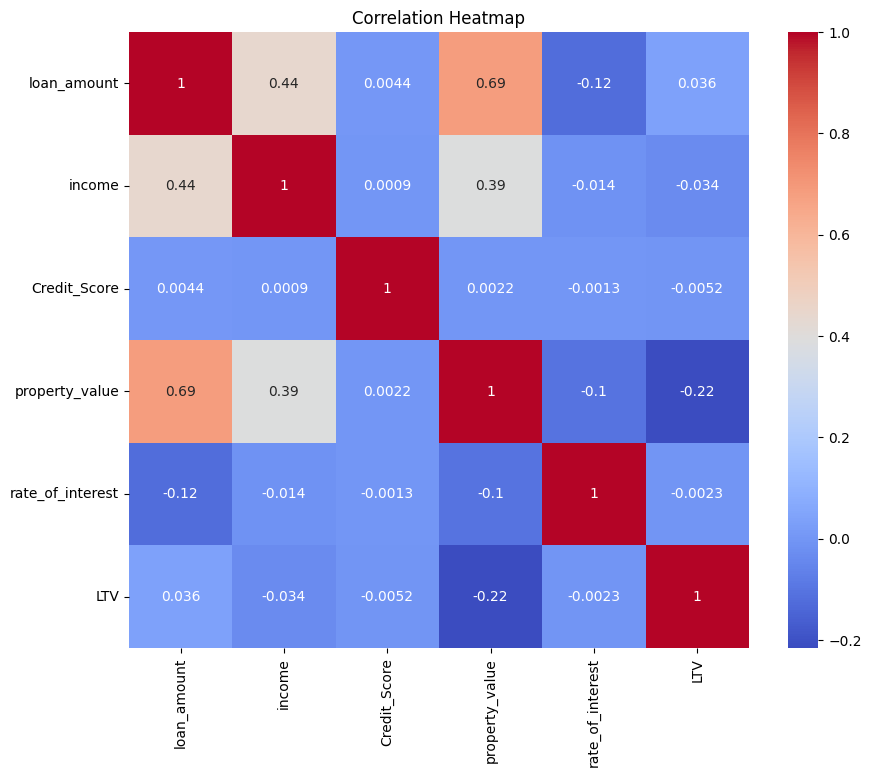

In [534]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df[
    [
        "loan_amount",
        "income",
        "Credit_Score",
        "property_value",
        "rate_of_interest",
        "LTV"
    ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [535]:
business_insights = pd.DataFrame({
    "Metric":[
        "Best Model",
        "Accuracy",
        "Top Important Feature"
    ],
    "Value":[
        best_model_name,
        str(round(rf_accuracy*100,2))+"%",
        feature_importance.iloc[0]["Feature"]
    ]
})

business_insights

,Metric,Value
0,Best Model,Decision Tree
1,Accuracy,90.2%
2,Top Important Feature,rate_of_interest


In [536]:
business_insights.to_csv(
    "business_insights.csv",
    index=False
)

In [537]:
print("Loan Default Prediction Project Completed Successfully")
print("Best Model :", best_model_name)
print("Model Accuracy :", round(rf_accuracy*100,2), "%")
print("Top Important Feature :", feature_importance.iloc[0]["Feature"])

Loan Default Prediction Project Completed Successfully
Best Model : Decision Tree
Model Accuracy : 90.2 %
Top Important Feature : rate_of_interest


In [538]:
print("Best Machine Learning Model:", best_model_name)

Best Machine Learning Model: Decision Tree


In [539]:
print("Best Model Accuracy:", round(rf_accuracy * 100, 2), "%")

Best Model Accuracy: 90.2 %


In [540]:
comparison

,Model,Accuracy,Accuracy (%),Precision,Recall,F1 Score
0,Logistic Regression,0.755129,75.512881,0.810169,0.755129,0.651428
1,Decision Tree,0.909397,90.939665,0.911116,0.909397,0.910100
2,Random Forest,0.901998,90.199771,0.902800,0.901998,0.902364


In [541]:
feature_importance.head(10)

,Feature,Importance
3,rate_of_interest,0.424211
4,property_value,0.130407
5,LTV,0.109805
6,Loan_Property_Ratio,0.091190
7,Income_Loan_Ratio,0.075923
2,Credit_Score,0.071948
1,income,0.062097
0,loan_amount,0.029335
9,High_Income,0.002954
8,High_Loan,0.002130


In [542]:
business_insights

,Metric,Value
0,Best Model,Decision Tree
1,Accuracy,90.2%
2,Top Important Feature,rate_of_interest


In [543]:
comparison.to_csv("Model_Comparison.csv", index=False)

feature_importance.to_csv("Feature_Importance.csv", index=False)

business_insights.to_csv("Business_Insights.csv", index=False)

In [544]:
print("="*60)

print("LOAN DEFAULT PREDICTION PROJECT SUMMARY")

print("="*60)

print("Dataset Successfully Cleaned")

print("Exploratory Data Analysis Completed")

print("Feature Engineering Completed")

print("Feature Selection Completed")

print("Models Trained Successfully")

print("Best Model:", best_model_name)

print("Accuracy:", round(rf_accuracy*100,2), "%")

print("="*60)

LOAN DEFAULT PREDICTION PROJECT SUMMARY
Dataset Successfully Cleaned
Exploratory Data Analysis Completed
Feature Engineering Completed
Feature Selection Completed
Models Trained Successfully
Best Model: Decision Tree
Accuracy: 90.2 %


In [545]:
print(df.shape)

(148670, 41)


In [546]:
print(X.columns.tolist())

['loan_amount', 'income', 'Credit_Score', 'rate_of_interest', 'property_value', 'LTV', 'Loan_Property_Ratio', 'Income_Loan_Ratio', 'High_Loan', 'High_Income']


In [547]:
print(df["Status"].value_counts())

Status
0    112031
1     36639
Name: count, dtype: int64


In [548]:
df.to_csv(
    "Final_Loan_Default_Dataset.csv",
    index=False
)

In [549]:
import joblib

joblib.dump(
    rf_model,
    "Final_Loan_Default_Model.pkl"
)

['Final_Loan_Default_Model.pkl']

In [550]:
loaded_model = joblib.load(
    "Final_Loan_Default_Model.pkl"
)

In [551]:
prediction = loaded_model.predict(X_test.iloc[[0]])

print("Prediction:", prediction)

Prediction: [0]


In [552]:
probability = loaded_model.predict_proba(X_test.iloc[[0]])

print(probability)

[[0.99 0.01]]


In [553]:
print("Loan Default Prediction Project Completed Successfully!")
print("Ready for GitHub, Resume and Interviews.")

Loan Default Prediction Project Completed Successfully!
Ready for GitHub, Resume and Interviews.
